# What is the fastest primary-drying cycle this equipment can run?

This tutorial treats optimizer equivalence as validation, not as the product. Its engineering result is the fastest **implementable** joint shelf-temperature/chamber-pressure cycle for stated starting controls and actuator slew limits. It then asks which constraints cost time and whether faster actuators would materially shorten the cycle.

The legacy sequential SciPy optimizer supplies an independent rate-unlimited reference. Pyomo.DAE is required for the implementable problem because adjacent control decisions are coupled by rates; the sequential optimizer cannot express those intertemporal constraints. The final validation appendix reports runtime only beside the accuracy each configuration buys.


## Decision contract and interpretation boundary

The nominal case uses a product critical temperature of -25 °C, the package equipment-capability curve, chamber-pressure bounds of 0.05–0.50 Torr, and shelf-temperature bounds of -45–120 °C. The operational cycle starts at 0.15 Torr and -35 °C. Its baseline rates are 0.05 Torr/hr and 10 °C/hr, matching the earlier conservative study.

These are adjacent-node secant limits in optimized physical time. They make the controls executable at the stated rates, but they do not add shelf, vial, or product thermal capacitance. Temperatures remain quasi-steady algebraic states. Replace the rate inputs with qualified site-specific equipment data before using the result for a real cycle.


## Optional solver setup

Run from the repository root after installing the optional stack:

```bash
python -m pip install -e ".[dev,pyomo]"
idaes get-extensions --extra petsc
export PATH="$HOME/.idaes/bin:$PATH"
jupyter lab docs/examples/current_main_joint_optimizer_comparison.ipynb
```

A conda-forge IPOPT installation can be used instead.


In [1]:
# Papermill parameters: CI overrides these with a small smoke case.
a1 = 16.0
kc = 2.75e-4
scipy_dt = 0.01
scipy_dt_values = [0.1, 0.05, 0.02, 0.01]
validation_point_budget = 25
analysis_point_budget = 97
sweep_point_budget = 49
sensitivity_point_budgets = [25, 49, 73]
ncp = 3
final_dried_fraction = 1.0
timing_repeats = 3
initial_pressure_torr = 0.15
initial_shelf_temperature_c = -35.0
pressure_ramp_rate_torr_hr = 0.05
shelf_temperature_ramp_rate_c_hr = 10.0
pressure_sweep_rates_torr_hr = [0.025, 0.05, 0.10]
shelf_sweep_rates_c_hr = [30.0, 45.0, 60.0]
constraint_tolerance = 1.0e-4
scipy_temperature_tolerance_c = 0.5
save_results = False
results_dir = "benchmarks/results/implementable_cycle"


In [2]:
import json
import platform
import subprocess
from importlib.metadata import version
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pyomo
import scipy

from examples.current_main_joint_optimizer_comparison import (
    comparison_inputs,
    matched_nfe_for_point_budget,
    run_case_comparison,
    run_discretization_sensitivity,
    run_implementability_analysis,
    run_pyomo_dae,
    run_scipy_reference,
    run_slew_rate_sweep,
    trajectory_constraint_diagnostics,
)


In [3]:
try:
    git_revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    git_revision = "unavailable"

environment = {
    "git_revision": git_revision,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "lyopronto": version("lyopronto"),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "pyomo": pyomo.__version__,
    "matplotlib": matplotlib.__version__,
}
environment


{'git_revision': 'edf3926ec5b1df145cd4be088b30da059c301ebb',
 'python': '3.13.9',
 'platform': 'Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39',
 'lyopronto': '1.1.0',
 'numpy': '2.5.0',
 'scipy': '1.17.1',
 'pyomo': '6.9.5',
 'matplotlib': '3.10.9'}

## Headline: the fastest implementable cycle

Four counterfactual solves distinguish the idealized optimum from the operational cycle:

1. **Idealized:** no fixed starting controls and no slew limits.
2. **Anchored only:** operational starts, but the next node may jump.
3. **Pressure preconditioned:** pressure starts at its 0.05 Torr optimum; the -35 °C shelf start and both rates remain.
4. **Implementable:** both operational starts and both rates.

This is more informative than subtracting a two-hour pressure transit from the cycle time: drying continues during that transit, and starting conditions only become costly through their interaction with rate limits.


In [4]:
analysis = run_implementability_analysis(
    a1,
    kc,
    point_budget=analysis_point_budget,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
    initial_pressure_torr=initial_pressure_torr,
    initial_shelf_temperature_c=initial_shelf_temperature_c,
    pressure_ramp_rate_torr_hr=pressure_ramp_rate_torr_hr,
    shelf_temperature_ramp_rate_c_hr=shelf_temperature_ramp_rate_c_hr,
)

scenario_runs = {
    "Idealized": analysis.idealized,
    "Anchored; jumps unlimited": analysis.anchored_unlimited,
    "Pressure preconditioned": analysis.pressure_preconditioned,
    "Implementable": analysis.implementable,
}
data = comparison_inputs(a1, kc)
print(f"{'scenario':>28} {'time [h]':>10} {'penalty [h]':>13} {'penalty [%]':>13}")
for label, run in scenario_runs.items():
    diagnostics = trajectory_constraint_diagnostics(run.trajectory, data)
    assert run.success
    assert diagnostics["final_dried_percent"] >= 100.0 * final_dried_fraction - 1.0e-3
    assert diagnostics["product_temperature_violation_c"] <= constraint_tolerance
    assert diagnostics["minimum_equipment_margin_kg_hr"] >= -1.0e-6
    penalty_hr = run.objective_time_hr - analysis.idealized.objective_time_hr
    penalty_percent = 100.0 * penalty_hr / analysis.idealized.objective_time_hr
    print(f"{label:>28} {run.objective_time_hr:10.4f} {penalty_hr:13.4f} {penalty_percent:13.2f}")


                    scenario   time [h]   penalty [h]   penalty [%]
                   Idealized    10.7604        0.0000          0.00
   Anchored; jumps unlimited    10.7604       -0.0000         -0.00
     Pressure preconditioned    13.3275        2.5671         23.86
               Implementable    13.4207        2.6603         24.72



Anchor-first additive decomposition
  anchors only (jumps unlimited)       -0.0000 h
  rates + start/rate interaction        2.6603 h

Conditional operational decomposition
  rates + -35 °C shelf start            2.5671 h
  150 mTorr pressure start              0.0932 h


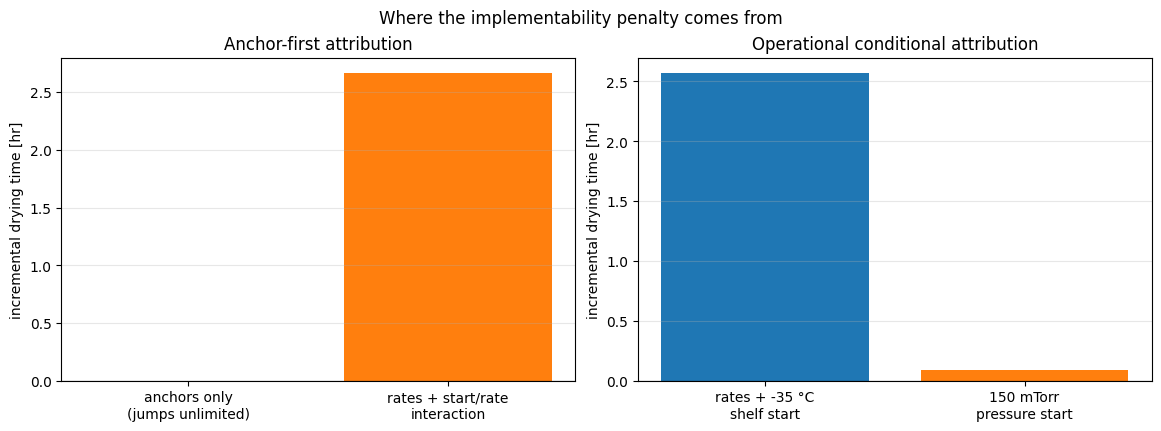

In [5]:
assert np.isclose(
    analysis.total_penalty_hr,
    analysis.anchor_only_penalty_hr + analysis.rate_and_interaction_penalty_hr,
)
assert np.isclose(
    analysis.total_penalty_hr,
    analysis.preconditioned_penalty_hr + analysis.pressure_start_penalty_hr,
)

decomposition_rows = [
    ("anchors only\n(jumps unlimited)", analysis.anchor_only_penalty_hr),
    ("rates + start/rate\ninteraction", analysis.rate_and_interaction_penalty_hr),
]
conditional_rows = [
    ("rates + -35 °C\nshelf start", analysis.preconditioned_penalty_hr),
    ("150 mTorr\npressure start", analysis.pressure_start_penalty_hr),
]
print("\nAnchor-first additive decomposition")
for label, value in decomposition_rows:
    print(f"  {label.replace(chr(10), ' '):35s} {value:8.4f} h")
print("\nConditional operational decomposition")
for label, value in conditional_rows:
    print(f"  {label.replace(chr(10), ' '):35s} {value:8.4f} h")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained")
for ax, rows, title in (
    (axes[0], decomposition_rows, "Anchor-first attribution"),
    (axes[1], conditional_rows, "Operational conditional attribution"),
):
    ax.bar([label for label, _ in rows], [value for _, value in rows], color=["tab:blue", "tab:orange"])
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set(title=title, ylabel="incremental drying time [hr]")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Where the implementability penalty comes from")
plt.show()


The anchor-only solve is intentionally part of the decomposition. If its penalty is near zero, that does **not** mean starting conditions are irrelevant; it means a fixed value at one node costs nothing while an instantaneous next-node jump is allowed. The full penalty is created by the start/rate interaction.

The pressure-preconditioned counterfactual isolates the 150 mTorr pressure start while holding the shelf start and both rate limits fixed. Its incremental completion-time cost can be much smaller than the raw `(0.15 - 0.05) / 0.05 = 2 hr` transit because the batch keeps drying as pressure falls.


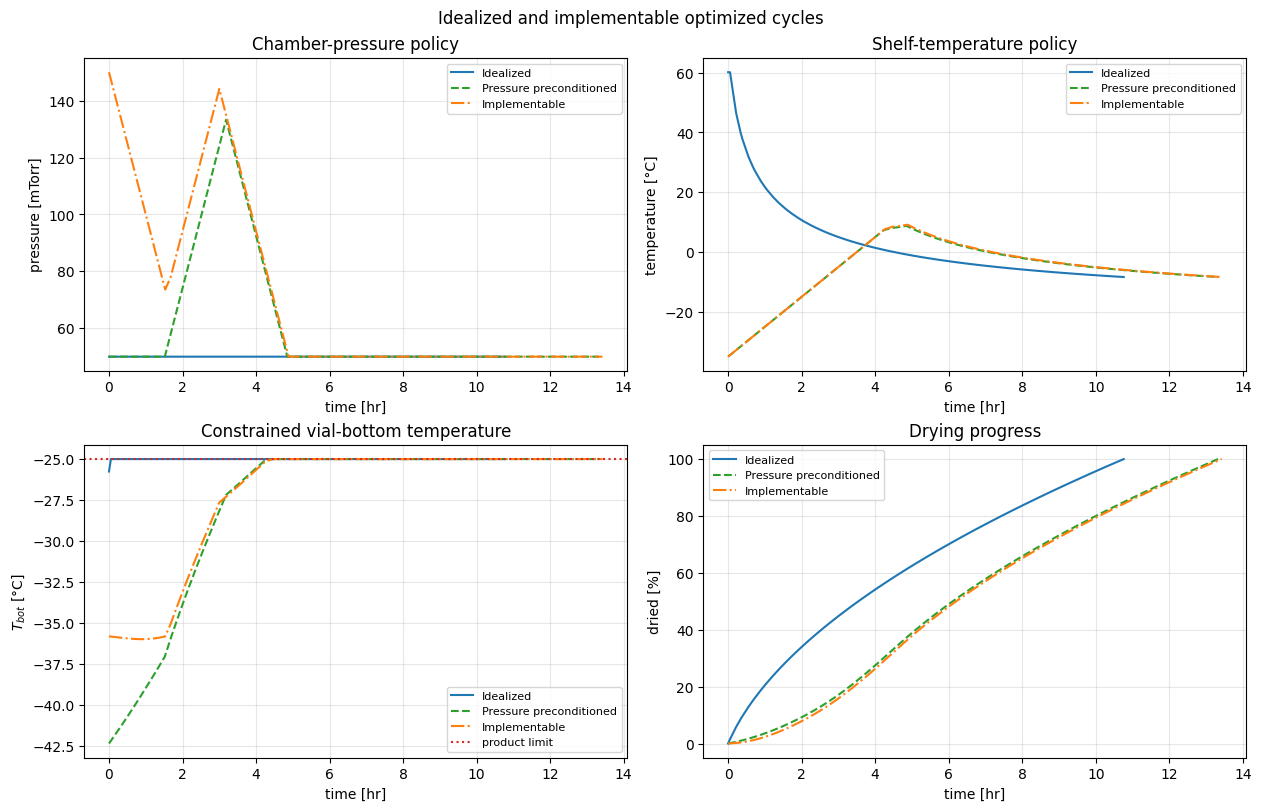

In [6]:
trajectory_styles = {
    "Idealized": ("tab:blue", "-"),
    "Pressure preconditioned": ("tab:green", "--"),
    "Implementable": ("tab:orange", "-."),
}
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), layout="constrained")
for label in trajectory_styles:
    table = scenario_runs[label].trajectory
    color, linestyle = trajectory_styles[label]
    axes[0, 0].plot(table[:, 0], table[:, 4], label=label, color=color, linestyle=linestyle)
    axes[0, 1].plot(table[:, 0], table[:, 3], label=label, color=color, linestyle=linestyle)
    axes[1, 0].plot(table[:, 0], table[:, 2], label=label, color=color, linestyle=linestyle)
    axes[1, 1].plot(table[:, 0], table[:, 6], label=label, color=color, linestyle=linestyle)

axes[0, 0].set(title="Chamber-pressure policy", ylabel="pressure [mTorr]")
axes[0, 1].set(title="Shelf-temperature policy", ylabel="temperature [°C]")
axes[1, 0].axhline(data["product"]["T_pr_crit"], color="tab:red", linestyle=":", label="product limit")
axes[1, 0].set(title="Constrained vial-bottom temperature", ylabel="$T_{bot}$ [°C]")
axes[1, 1].set(title="Drying progress", ylabel="dried [%]")
for ax in axes.flat:
    ax.set_xlabel("time [hr]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Idealized and implementable optimized cycles")
plt.show()


## Would faster actuators buy useful cycle time?

The shelf sweep uses 30–60 °C/hr, equivalent to 0.5–1.0 °C/min, the realistic envelope specified for this study. Pressure response is more equipment- and recipe-dependent, so 0.025–0.10 Torr/hr is an explicit scenario range around the 0.05 Torr/hr baseline—not a universal equipment specification. Every point retains the operational 0.15 Torr and -35 °C starts and is compared with an idealized solve on the same mesh.


  P rate [Torr/hr]   shelf rate [°C/hr]   time [h]   penalty [%]
             0.025                 30.0    11.9894         11.42
             0.025                 45.0    11.7368          9.07
             0.025                 60.0    11.6237          8.02
             0.050                 30.0    11.8623         10.24
             0.050                 45.0    11.5610          7.44
             0.050                 60.0    11.4221          6.15
             0.100                 30.0    11.8414         10.05
             0.100                 45.0    11.5367          7.21
             0.100                 60.0    11.3667          5.63


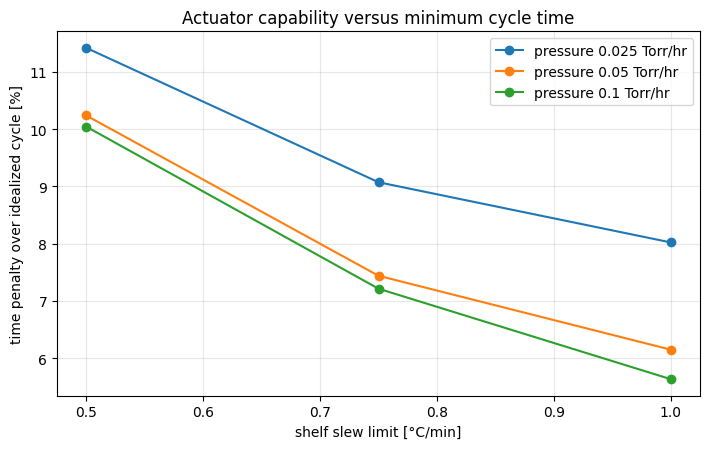

In [7]:
_, sweep_collocation_nfe = matched_nfe_for_point_budget(sweep_point_budget, ncp)
sweep_idealized = run_pyomo_dae(
    a1,
    kc,
    discretization="collocation",
    nfe=sweep_collocation_nfe,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
)
assert sweep_idealized.success
sweep_rows = run_slew_rate_sweep(
    a1,
    kc,
    sweep_idealized.objective_time_hr,
    pressure_ramp_rates_torr_hr=pressure_sweep_rates_torr_hr,
    shelf_temperature_ramp_rates_c_hr=shelf_sweep_rates_c_hr,
    point_budget=sweep_point_budget,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
    initial_pressure_torr=initial_pressure_torr,
    initial_shelf_temperature_c=initial_shelf_temperature_c,
)

print(f"{'P rate [Torr/hr]':>18} {'shelf rate [°C/hr]':>20} {'time [h]':>10} {'penalty [%]':>13}")
for row in sweep_rows:
    print(
        f"{row['pressure_ramp_rate_torr_hr']:18.3f} "
        f"{row['shelf_temperature_ramp_rate_c_hr']:20.1f} "
        f"{row['objective_time_hr']:10.4f} {row['penalty_percent']:13.2f}"
    )

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for pressure_rate in pressure_sweep_rates_torr_hr:
    rows = [
        row for row in sweep_rows
        if np.isclose(row["pressure_ramp_rate_torr_hr"], pressure_rate)
    ]
    ax.plot(
        [row["shelf_temperature_ramp_rate_c_hr"] / 60.0 for row in rows],
        [row["penalty_percent"] for row in rows],
        marker="o",
        label=f"pressure {pressure_rate:g} Torr/hr",
    )
ax.set(
    xlabel="shelf slew limit [°C/min]",
    ylabel="time penalty over idealized cycle [%]",
    title="Actuator capability versus minimum cycle time",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


A flatter pressure-rate curve means pressure response is no longer the best investment in that region; vertical separation between shelf-rate points quantifies the remaining shelf-controller opportunity. This is a local model-based capital screen, not a purchase recommendation: repeat it with qualified equipment limits and a validated process model.


## Which physical constraints are worth relaxing?

IPOPT multipliers exposed through `DaeOptimizationResult.shadow_prices` give the local change in optimal drying time per unit increase in each named limit. Positive means raising the limit costs time; negative means it saves time. Near-zero values identify inactive constraints. The idealized result is used here because its active set is the cleanest capability diagnostic; ramp-rate sensitivities are evaluated by the finite sweeps above.


In [8]:
shadow_units = {
    "product_temperature_limit": "hr/°C",
    "equipment_capability": "hr/(kg/hr)",
    "final_drying_target": "hr/cm",
    "chamber_pressure_lower_bound": "hr/Torr",
    "chamber_pressure_upper_bound": "hr/Torr",
    "shelf_temperature_lower_bound": "hr/°C",
    "shelf_temperature_upper_bound": "hr/°C",
}
shadow_rows = [
    {
        "constraint": name,
        "shadow_price": value,
        "units": shadow_units[name],
        "binding": not np.isclose(value, 0.0, atol=1.0e-3),
    }
    for name, value in analysis.idealized.shadow_prices.items()
]
print(f"{'constraint':>34} {'shadow price':>15} {'units':>14} {'binding?':>10}")
for row in shadow_rows:
    print(
        f"{row['constraint']:>34} {row['shadow_price']:15.6g} "
        f"{row['units']:>14} {str(row['binding']):>10}"
    )

decision_prices = {
    row["constraint"]: row["shadow_price"]
    for row in shadow_rows
    if row["constraint"] != "final_drying_target"
}
assert decision_prices["product_temperature_limit"] < 0.0
assert decision_prices["chamber_pressure_lower_bound"] > 0.0
assert abs(decision_prices["equipment_capability"]) < 1.0e-3
assert abs(decision_prices["shelf_temperature_lower_bound"]) < 1.0e-3
assert abs(decision_prices["shelf_temperature_upper_bound"]) < 1.0e-3


                        constraint    shadow price          units   binding?
         product_temperature_limit        -1.13901          hr/°C       True
              equipment_capability     -1.4906e-05     hr/(kg/hr)      False
               final_drying_target         26.1628          hr/cm       True
      chamber_pressure_lower_bound         25.4377        hr/Torr       True
      chamber_pressure_upper_bound    -1.07509e-05        hr/Torr      False
     shelf_temperature_lower_bound     1.06177e-07          hr/°C      False
     shelf_temperature_upper_bound    -4.23574e-08          hr/°C      False


The active set answers the investment question directly. More product-temperature headroom has value (negative `product_temperature_limit` price), while raising the chamber-pressure floor costs time (positive lower-bound price). Additional equipment-capability-curve margin, wider shelf bounds, and a higher pressure ceiling are locally worthless in this regime because their prices are near zero. Better vial contact therefore cannot shorten this already product-temperature-limited nominal cycle; better vacuum capability can.


## Validation appendix: agreement and speed at stated accuracy

The implementable calculation is credible only if the rate-unlimited DAE reproduces an independent reference. The table below compares one nominal SciPy trajectory with finite differences and collocation at equal DAE point count. Runtime is always displayed beside final-time error. An “accuracy-matched” speedup uses the tested SciPy step whose absolute error is closest to collocation's error, rather than comparing collocation only with the finest and most expensive reference.


                method  points/steps   time [h]   error [%]   wall [s]
          SciPy dt=0.1           108   10.67333     -0.7303     0.4339
         SciPy dt=0.05           216   10.71734     -0.3210     0.8598
         SciPy dt=0.02           539   10.74327     -0.0797     2.1447
         SciPy dt=0.01          1077   10.75185      0.0000     4.2342
     finite difference            25   11.12551      3.4754     0.0488
           collocation            25   10.76078      0.0830     0.0465

Closest tested accuracy: SciPy dt=0.02 (-0.0797%) versus collocation (+0.0830%); accuracy-matched speedup = 46.1x.
Finest SciPy step-halving movement = 0.0797%; collocation gap = 0.0830%.


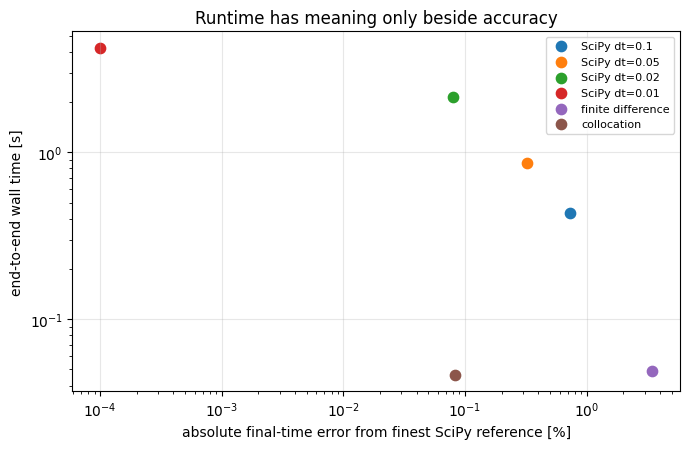

In [9]:
validation_fd_nfe, validation_collocation_nfe = matched_nfe_for_point_budget(
    validation_point_budget, ncp
)
validation = run_case_comparison(
    a1,
    kc,
    scipy_dt=scipy_dt,
    finite_difference_nfe=validation_fd_nfe,
    collocation_nfe=validation_collocation_nfe,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
    timing_repeats=timing_repeats,
)

validation_tables = (
    ("SciPy", validation.scipy_trajectory, scipy_temperature_tolerance_c),
    (
        "finite difference",
        validation.finite_difference_trajectory,
        constraint_tolerance,
    ),
    ("collocation", validation.collocation_trajectory, constraint_tolerance),
)
for method, table, temperature_tolerance_c in validation_tables:
    diagnostics = trajectory_constraint_diagnostics(table, data)
    assert table.shape[1] == 7
    assert diagnostics["final_dried_percent"] >= (
        100.0 * final_dried_fraction - 1.0e-3
    )
    assert (
        diagnostics["product_temperature_violation_c"]
        <= temperature_tolerance_c
    ), method
    assert diagnostics["pressure_lower_violation_mtorr"] <= 1.0e-3
    assert diagnostics["pressure_upper_violation_mtorr"] <= 1.0e-3
    assert diagnostics["shelf_lower_violation_c"] <= constraint_tolerance
    assert diagnostics["shelf_upper_violation_c"] <= constraint_tolerance
    assert diagnostics["minimum_equipment_margin_kg_hr"] >= -1.0e-6

scipy_dt_values = sorted({float(value) for value in scipy_dt_values}, reverse=True)
assert scipy_dt_values and all(value > 0.0 for value in scipy_dt_values)
assert np.isclose(scipy_dt, min(scipy_dt_values))
scipy_accuracy_rows = []
for dt in scipy_dt_values:
    if np.isclose(dt, scipy_dt):
        objective_time_hr = validation.scipy_objective_time_hr
        wall_time_s = validation.scipy_wall_median_s
        n_points = validation.scipy_trajectory.shape[0]
    else:
        run = run_scipy_reference(a1, kc, dt=dt)
        assert run.success
        objective_time_hr = run.objective_time_hr
        wall_time_s = run.wall_time_s
        n_points = run.n_time_points
    scipy_accuracy_rows.append(
        {
            "method": f"SciPy dt={dt:g}",
            "dt": dt,
            "objective_time_hr": objective_time_hr,
            "wall_time_s": wall_time_s,
            "points": n_points,
        }
    )

reference_time_hr = scipy_accuracy_rows[-1]["objective_time_hr"]
accuracy_rows = scipy_accuracy_rows + [
    {
        "method": "finite difference",
        "dt": None,
        "objective_time_hr": validation.finite_difference_objective_time_hr,
        "wall_time_s": validation.finite_difference_wall_median_s,
        "points": validation.finite_difference_trajectory.shape[0],
    },
    {
        "method": "collocation",
        "dt": None,
        "objective_time_hr": validation.collocation_objective_time_hr,
        "wall_time_s": validation.collocation_wall_median_s,
        "points": validation.collocation_trajectory.shape[0],
    },
]
for row in accuracy_rows:
    row["gap_percent"] = 100.0 * (
        row["objective_time_hr"] - reference_time_hr
    ) / reference_time_hr

print(f"{'method':>22} {'points/steps':>13} {'time [h]':>10} {'error [%]':>11} {'wall [s]':>10}")
for row in accuracy_rows:
    print(
        f"{row['method']:>22} {row['points']:13d} "
        f"{row['objective_time_hr']:10.5f} {row['gap_percent']:11.4f} "
        f"{row['wall_time_s']:10.4f}"
    )

collocation_row = next(row for row in accuracy_rows if row["method"] == "collocation")
iso_accuracy_scipy = min(
    scipy_accuracy_rows[:-1],
    key=lambda row: abs(abs(row["gap_percent"]) - abs(collocation_row["gap_percent"])),
)
iso_accuracy_speedup = iso_accuracy_scipy["wall_time_s"] / collocation_row["wall_time_s"]
scipy_reference_resolution_percent = abs(
    scipy_accuracy_rows[-2]["objective_time_hr"] - reference_time_hr
) / reference_time_hr * 100.0
print(
    f"\nClosest tested accuracy: {iso_accuracy_scipy['method']} "
    f"({iso_accuracy_scipy['gap_percent']:+.4f}%) versus collocation "
    f"({collocation_row['gap_percent']:+.4f}%); "
    f"accuracy-matched speedup = {iso_accuracy_speedup:.1f}x."
)
print(
    f"Finest SciPy step-halving movement = {scipy_reference_resolution_percent:.4f}%; "
    f"collocation gap = {abs(collocation_row['gap_percent']):.4f}%."
)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
for row in accuracy_rows:
    ax.scatter(
        max(abs(row["gap_percent"]), 1.0e-4),
        row["wall_time_s"],
        s=55,
        label=row["method"],
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(
    xlabel="absolute final-time error from finest SciPy reference [%]",
    ylabel="end-to-end wall time [s]",
    title="Runtime has meaning only beside accuracy",
)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


For the default run, 25-point collocation is at or beyond the resolution of the 1,077-step SciPy reference: its residual gap is on the scale of the change caused by the final SciPy step halving. The reference therefore cannot support a claim that the remaining difference is DAE error. This is the validation result that licenses the implementability study; the speedup matters mainly for repeated design-space, estimation, or scenario solves.


## Validation appendix: transcription resolution

Backward Euler and Radau collocation are compared at equal transcription point count, not equal `nfe`. The sweep reports final-time error together with the actual scalar-variable and active-constraint counts. This makes clear that equal point count is a transparent resolution comparison, not a claim of identical NLP size.


              method  points  variables  constraints   error [%]   wall [s]
   finite_difference      25        251          253      3.4754     0.0546
         collocation      25        251          253      0.0830     0.0485
   finite_difference      49        491          493      1.8113     0.0775
         collocation      49        491          493      0.0799     0.0640
   finite_difference      73        731          733      1.2429     0.1097
         collocation      73        731          733      0.0795     0.1037


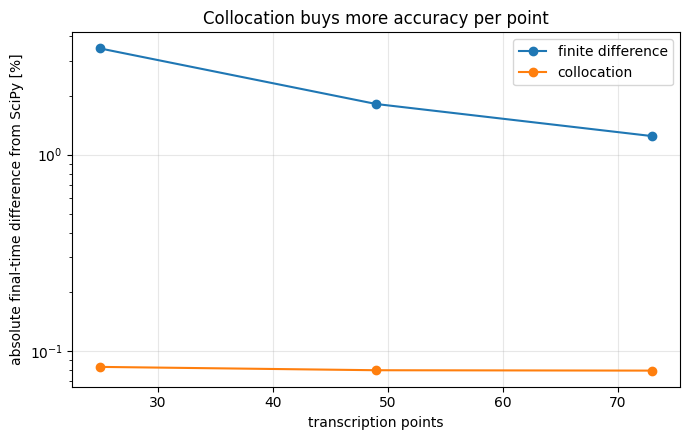

In [10]:
sensitivity_rows = run_discretization_sensitivity(
    a1,
    kc,
    validation.scipy_trajectory,
    point_budgets=sensitivity_point_budgets,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
)
print(f"{'method':>20} {'points':>7} {'variables':>10} {'constraints':>12} {'error [%]':>11} {'wall [s]':>10}")
for row in sensitivity_rows:
    print(
        f"{row['method']:>20} {row['n_time_points']:7d} "
        f"{row['n_variables']:10d} {row['n_constraints']:12d} "
        f"{row['objective_gap_percent']:11.4f} {row['wall_time_s']:10.4f}"
    )

fig, ax = plt.subplots(figsize=(7.0, 4.5))
for method in ("finite_difference", "collocation"):
    rows = [row for row in sensitivity_rows if row["method"] == method]
    ax.plot(
        [row["n_time_points"] for row in rows],
        [abs(row["objective_gap_percent"]) for row in rows],
        marker="o",
        label=method.replace("_", " "),
    )
ax.set_yscale("log")
ax.set(
    xlabel="transcription points",
    ylabel="absolute final-time difference from SciPy [%]",
    title="Collocation buys more accuracy per point",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## Why only one published optimizer-comparison tutorial?

Joint pressure/temperature control is the general capability example; shelf-only and pressure-only cases are obtained by fixing the other control. Their helper modules and solver-backed tests remain as regression fixtures for formulation equivalence, output shape, and convergence behavior, but publishing three near-identical narratives obscured the implementability result. This notebook is now the sole reader-facing comparison.


## Optionally save a compact reproduction record

Generated outputs belong under `benchmarks/results/`, which is ignored by default. The record retains environment details, scenario times, both penalty decompositions, the actuator sweep, shadow prices, and validation accuracy.


In [11]:
if save_results:
    destination = Path(results_dir)
    destination.mkdir(parents=True, exist_ok=True)
    payload = {
        "environment": environment,
        "parameters": {
            "a1": a1,
            "kc": kc,
            "initial_pressure_torr": initial_pressure_torr,
            "initial_shelf_temperature_c": initial_shelf_temperature_c,
            "pressure_ramp_rate_torr_hr": pressure_ramp_rate_torr_hr,
            "shelf_temperature_ramp_rate_c_hr": shelf_temperature_ramp_rate_c_hr,
        },
        "scenario_times_hr": {
            label: run.objective_time_hr for label, run in scenario_runs.items()
        },
        "penalties_hr": {
            "anchor_only": analysis.anchor_only_penalty_hr,
            "rate_and_interaction": analysis.rate_and_interaction_penalty_hr,
            "preconditioned": analysis.preconditioned_penalty_hr,
            "pressure_start": analysis.pressure_start_penalty_hr,
            "total": analysis.total_penalty_hr,
        },
        "slew_rate_sweep": sweep_rows,
        "shadow_prices": dict(analysis.idealized.shadow_prices),
        "accuracy_rows": accuracy_rows,
        "transcription_sensitivity": sensitivity_rows,
    }
    (destination / "summary.json").write_text(
        json.dumps(payload, indent=2) + "\n"
    )
    np.savez_compressed(
        destination / "trajectories.npz",
        **{
            label.lower().replace(" ", "_").replace(";", ""): run.trajectory
            for label, run in scenario_runs.items()
        },
    )
    print(f"Saved reproduction record under {destination}")
else:
    print("Set save_results=True to write JSON and NPZ outputs.")


Set save_results=True to write JSON and NPZ outputs.


## Interpretation boundaries

The headline result is capability: once starting conditions and control rates link successive decisions, the sequential SciPy optimizer cannot formulate the problem, while Pyomo.DAE can optimize it and price its active constraints. Runtime is secondary and is reported only with accuracy.

The default actuator study is intentionally transparent about counterfactual attribution. Anchors alone permit immediate jumps and cost essentially nothing; the operational penalty arises through the anchor/rate interaction. Preconditioning pressure isolates only the pressure-start increment conditional on the shelf start and both rates. The realistic shelf sweep shows how the answer changes across 0.5–1.0 °C/min, while pressure scenarios must be replaced with site data.

Shadow prices are local sensitivities around one active set, and slew-rate curves are finite re-solves. Neither replaces experimental model validation, controller qualification, or a thermal-capacitance model when transient shelf, vial, and product temperatures matter.
